In [ ]:
from pprint import pprint

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils.dirs import data_dir
from utils.dirs import plots_dir
from scripts.defaults import esr_codes

#### List of Facilities (Batteries)

In [ ]:
esr_codes

['ALINTA_WGP_ESR1',
 'COLLIE_BESS2',
 'COLLIE_ESR1',
 'COLLIE_ESR4',
 'COLLIE_ESR5',
 'KWINANA_ESR1',
 'KWINANA_ESR2',
 'PRDSO_WALPOLE_HG1',
 'SBSOLAR1_CUNDERDIN_PV1',
 'TESLA_PICTON_G1']

In [103]:
scada_filename = "wem_battery_scada.csv"
original = (
    pd.read_csv(data_dir / scada_filename, 
                parse_dates=["dispatchInterval"],
                dtype={"code": "category"})
    .assign(dispatchInterval=lambda d: d["dispatchInterval"].dt.tz_convert("Australia/Perth"))
    .set_index("dispatchInterval")
    .rename(columns={"quantity": "MWh"})
    )

In [15]:
original.info(memory_usage="deep")
original.memory_usage(deep=True).sort_values(ascending=False) / 1e6   # MB per column

<class 'pandas.DataFrame'>
DatetimeIndex: 1690272 entries, 2023-10-01 08:00:00+08:00 to 2026-08-02 07:55:00+08:00
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype   
---  ------  --------------    -----   
 0   code    1690272 non-null  category
 1   MWh     1690272 non-null  float64 
dtypes: category(1), float64(1)
memory usage: 27.4 MB


Index    13.522176
MWh      13.522176
code      1.691200
dtype: float64

In [ ]:
df = original.copy()

# Change sign to: (+) charging, (-) discharging
df["MWh"] = (-df["MWh"]).replace(-0.0, 0.0)

# Add MW column for average power within 5 min interval
df["MW"] = df["MWh"] * 12

# Get facilities list
facilities_filename = "facilities.csv"
facilities = pd.read_csv(data_dir / facilities_filename)

facilities = facilities.loc[facilities["Facility Code"].isin(esr_codes)]
system_size = (facilities.set_index("Facility Code")[["System Size (MW)"]]
               .sort_index()
               )


# Add rated power to df
df["system_size_MW"] = df["code"].map(system_size["System Size (MW)"])
df["power_percent"] = df["MW"] / df["system_size_MW"] * 100

df.head()

,code,MWh,MW,system_size_MW,power_percent
dispatchInterval,,,,,
2023-10-01 08:00:00+08:00,KWINANA_ESR1,0.06,0.72,200.0,0.36
2023-10-01 08:05:00+08:00,KWINANA_ESR1,0.06,0.72,200.0,0.36
2023-10-01 08:10:00+08:00,KWINANA_ESR1,0.06,0.72,200.0,0.36
2023-10-01 08:15:00+08:00,KWINANA_ESR1,0.06,0.72,200.0,0.36
2023-10-01 08:20:00+08:00,KWINANA_ESR1,0.06,0.72,200.0,0.36


In [112]:
esr_battery_codes = sorted([
    "ALINTA_WGP_ESR1",
    "COLLIE_BESS2",
    "COLLIE_ESR1",
    "COLLIE_ESR4",
    "COLLIE_ESR5",
    "KWINANA_ESR1",
    "KWINANA_ESR2",
    # "SBSOLAR1_CUNDERDIN_PV1",
    # "TESLA_PICTON_G1",
    # "PRDSO_WALPOLE_HG1",  # fuel type: hydro
])
esr = df.copy()
esr = esr.loc[esr["code"].isin(esr_battery_codes)]

esr["code"].unique()

['KWINANA_ESR1', 'COLLIE_ESR1', 'KWINANA_ESR2', 'COLLIE_BESS2', 'COLLIE_ESR4', 'COLLIE_ESR5', 'ALINTA_WGP_ESR1']
Categories (10, str): ['COLLIE_ESR1', 'KWINANA_ESR1', 'KWINANA_ESR2', 'SBSOLAR1_CUNDERDIN_PV1', ..., 'PRDSO_WALPOLE_HG1', 'COLLIE_ESR4', 'COLLIE_ESR5', 'ALINTA_WGP_ESR1']

### System Size (MW)

In [102]:
system_size

,System Size (MW)
Facility Code,
ALINTA_WGP_ESR1,200.000
COLLIE_BESS2,600.000
COLLIE_ESR1,400.000
COLLIE_ESR4,500.000
COLLIE_ESR5,500.000
KWINANA_ESR1,200.000
KWINANA_ESR2,450.000
PRDSO_WALPOLE_HG1,1.500
SBSOLAR1_CUNDERDIN_PV1,100.000


---

#### Functions

In [115]:

def build_boxplot(df: pd.DataFrame, col: str, title: str, y_label: str, battery_codes: list, show_outliers: bool = False, save_plot: bool = False, filepath: str | None = None):
    groups = df.groupby("code")[f"{col}"]
    codes = sorted(battery_codes)

    data = []
    for code in codes:
        values = groups.get_group(code)
        data.append(values.values)

    fig, ax = plt.subplots(figsize=(10, 6))
    
    bp = ax.boxplot(
        x=data, 
        showfliers=show_outliers, 
        # whis=(5,95),
        patch_artist=True,
        medianprops={"color": "black", "linewidth": 1.5}
        )

    colours = plt.cm.tab10(np.linspace(0, 1, 10))
    for patch, colour, code in zip(bp["boxes"], colours, codes):
        patch.set_facecolor(colour)
        patch.set_alpha(0.7)
        patch.set_edgecolor("black")
        patch.set_label(code)          # this is what the legend picks up

    ax.legend(handles=bp["boxes"], loc="upper left",
              bbox_to_anchor=(1.01, 1), frameon=False)
        
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)
    ax.set_xticks([])                  # drop the tick labels entirely
    ax.set_xlabel("Battery codes")
    ax.set_ylabel(f"{y_label}")
    ax.set_title(title, pad=1.5)
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    
    if save_plot and filepath is not None:
        fig.savefig(filepath, dpi=200)
        
    fig.show()

In [139]:
def plot_distribution_hist(df: pd.DataFrame, col: str, x_label: str, title: str, battery_codes: list):
    codes = sorted(c for c in battery_codes if c in df["code"].unique())
    n = len(codes)
    cols = min(3, n)
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.5 * rows),
                            sharex=False, squeeze=False)
    fig.suptitle(title, fontsize=13)

    for ax, code in zip(axes.flat, codes):
        vals = df.loc[df["code"] == code, col].dropna()
        ax.hist(vals, bins=100, color="tab:blue", alpha=0.8)
        ax.axvline(0, color="grey", lw=0.8)
        ax.set_yscale("log")
        ax.set_title(f"{code}  (n={len(vals):,})", fontsize=9)
        ax.set_xlabel(x_label)

    for ax in axes.flat[n:]:
        ax.set_visible(False)

    fig.tight_layout()


In [140]:

def avg_charge_profile(df: pd.DataFrame, start_time: str, end_time: str, y_label: str, title: str):
    df = df.between_time(start_time, end_time)
    df["time_of_day"] = df.index.strftime("%H:%M")

    profile = df.pivot_table(index="time_of_day", columns="code",
                            values="power_percent", aggfunc="mean").sort_index()
    profile = profile[sorted(profile.columns)]

    fig, ax = plt.subplots(figsize=(9, 5))
    profile.plot(ax=ax)
    ax.axhline(0, color="grey", lw=0.8)
    ax.set_ylabel(f"Average {y_label}\n(+) charging, (-) discharging")
    ax.set_xlabel("Time of day")
    ax.set_title(f"Average {title}")
    ax.legend(title="Battery Codes")
    fig.tight_layout()
    

---

## Energy Distribution Boxplot

Note: the boxplot does not capture accurate information about datapoints distribution as outliers are not shown.

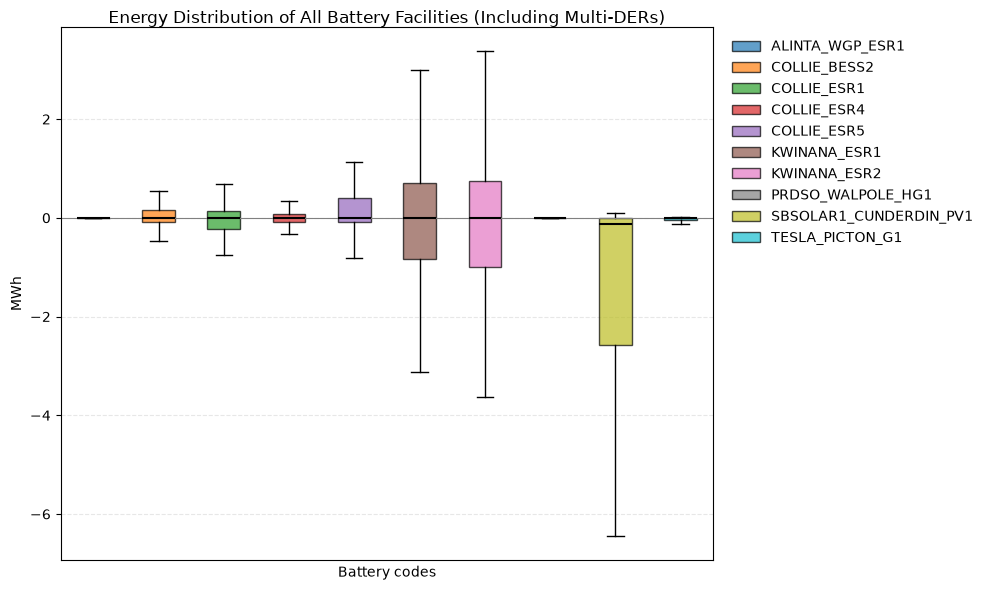

In [ ]:
build_boxplot(
    df=df,
    col="MWh",
    title="Energy Distribution of All Battery Facilities (Including Multi-DERs)",
    y_label="MWh",
    battery_codes=esr_codes
)

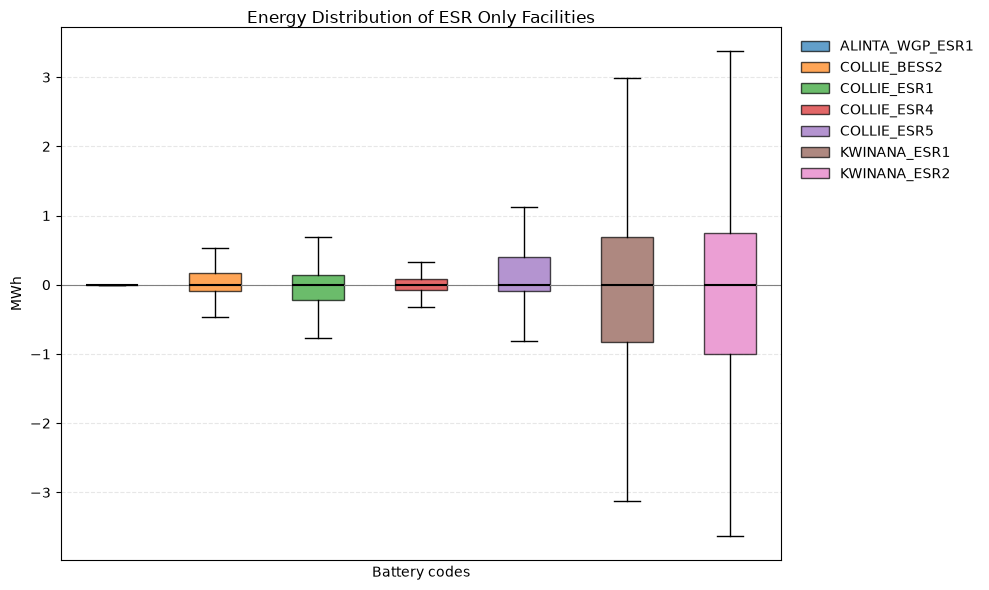

In [119]:
build_boxplot(
    df=esr,
    col="MWh",
    title="Energy Distribution of ESR Only Facilities",
    y_label="MWh",
    battery_codes=esr_battery_codes,
)

## Power Distribution Boxplot
Note: all batteries only charge/discharge below 50% of its rated power.

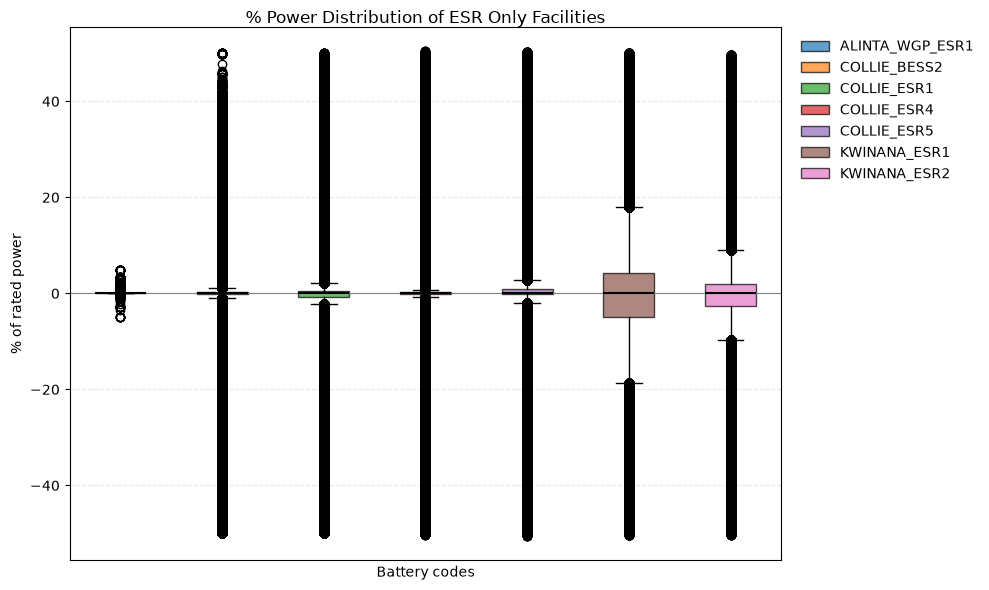

In [143]:
build_boxplot(
    df=esr,
    col="power_percent",
    title="% Power Distribution of ESR Only Facilities",
    y_label="% of rated power",
    battery_codes=esr_battery_codes,
    show_outliers=True
)

---

## Energy Distribution Histogram

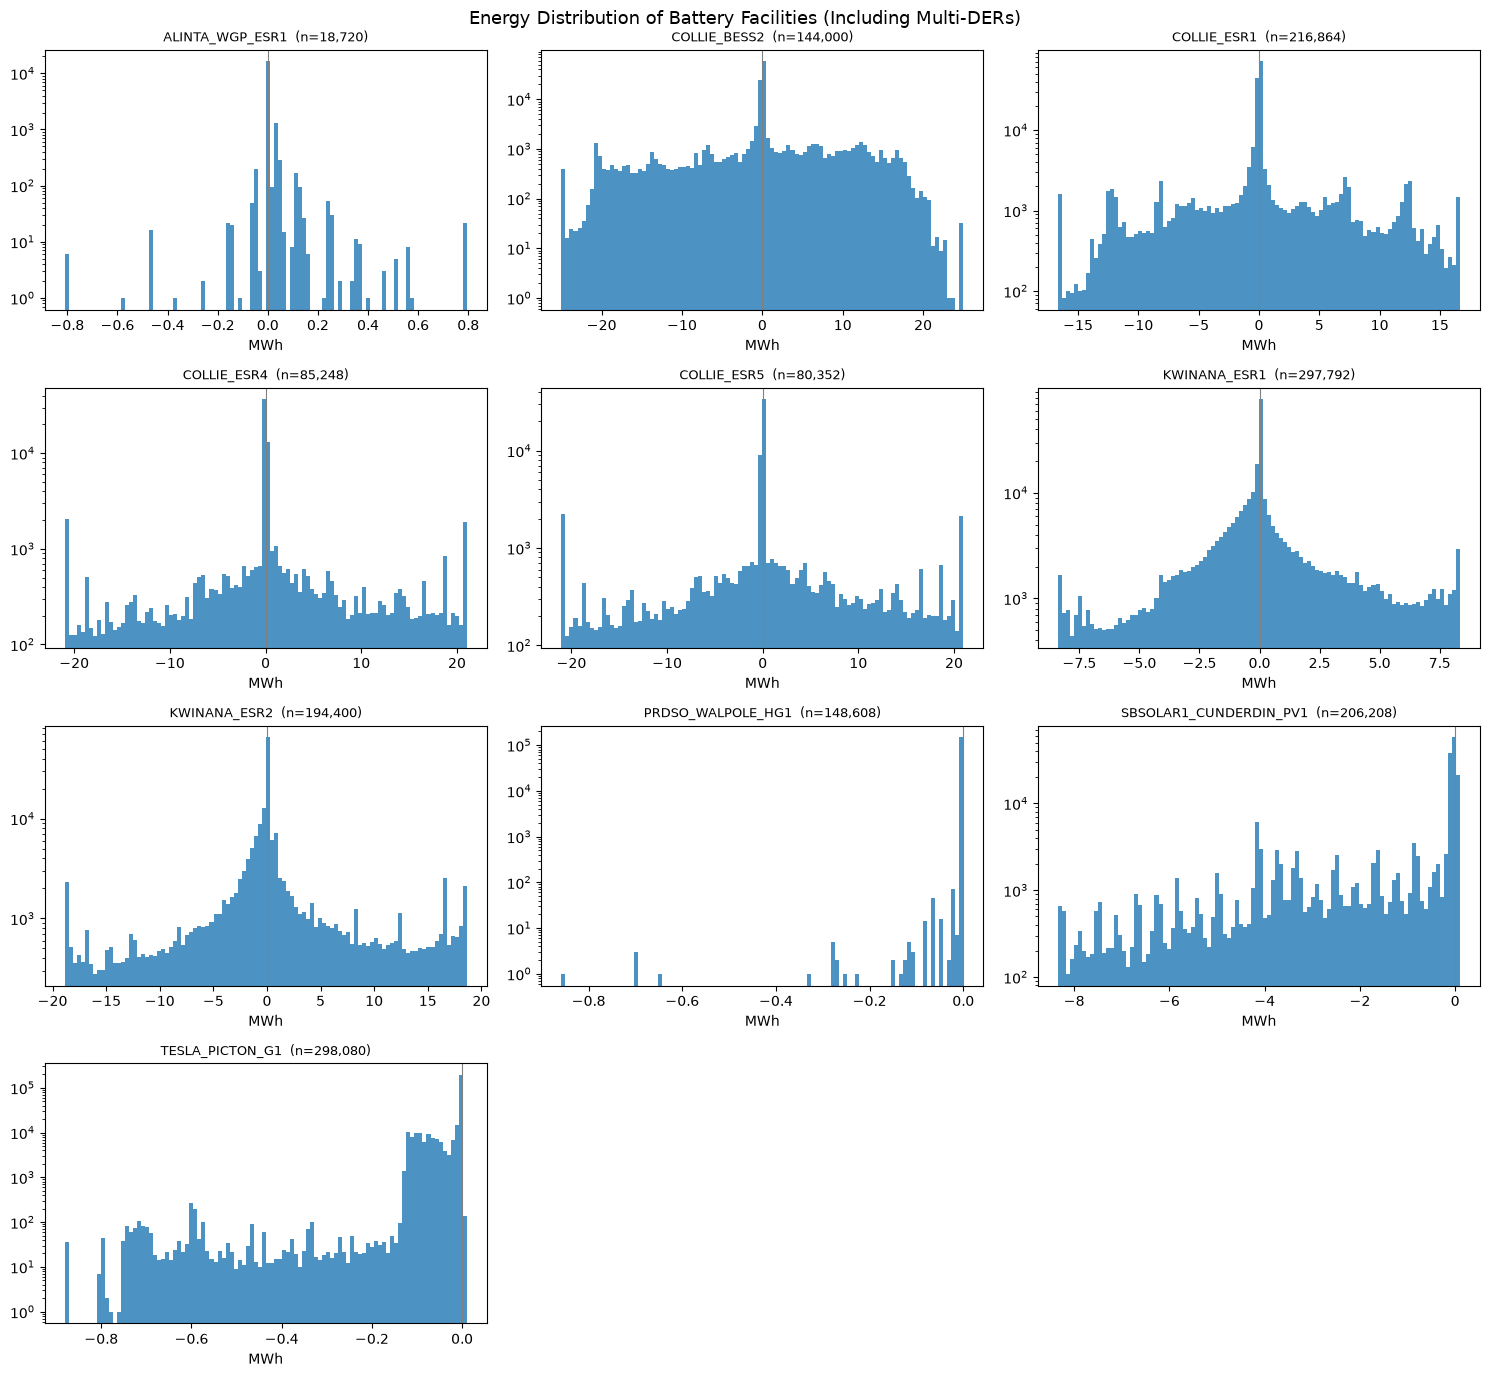

In [ ]:
plot_distribution_hist(
    df=df,
    col="MWh",
    x_label="MWh",
    title="Energy Distribution of Battery Facilities (Including Multi-DERs)",
    battery_codes=esr_codes
)

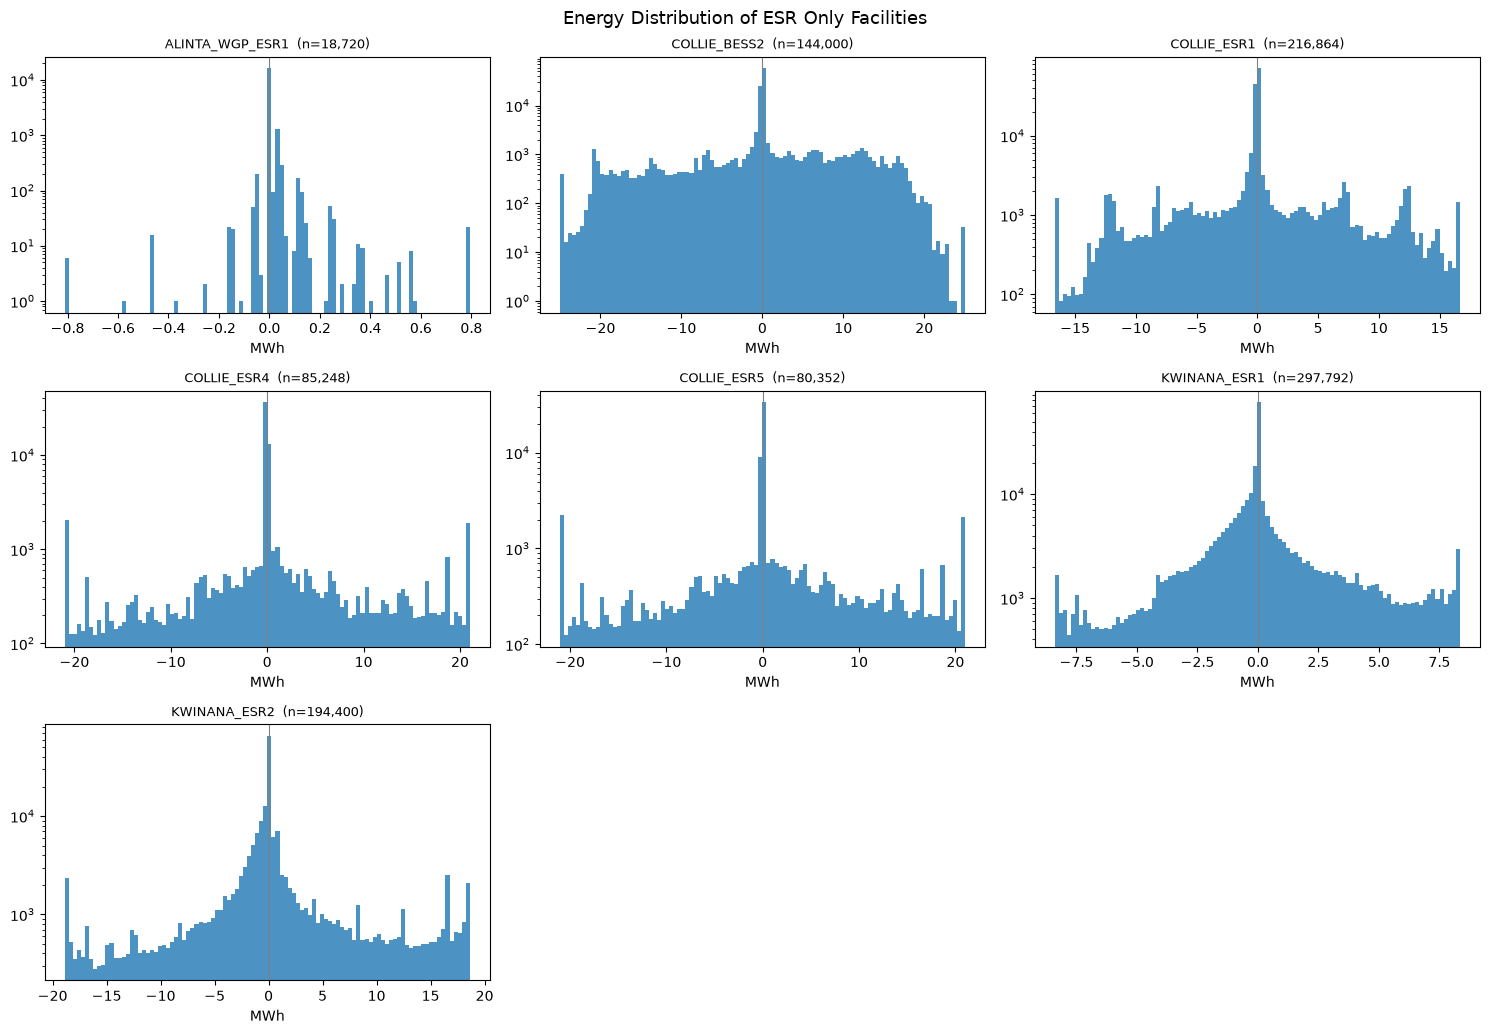

In [86]:
plot_distribution_hist(
    df=esr,
    col="MWh",
    x_label="MWh",
    title="Energy Distribution of ESR Only Facilities",
    battery_codes=esr_battery_codes
)

---

## Analysis during Peak Hours (15:00-21:00)

In [124]:
peak_start = "15:00"
peak_end = "21:00"
peak = esr.between_time(peak_start, peak_end)

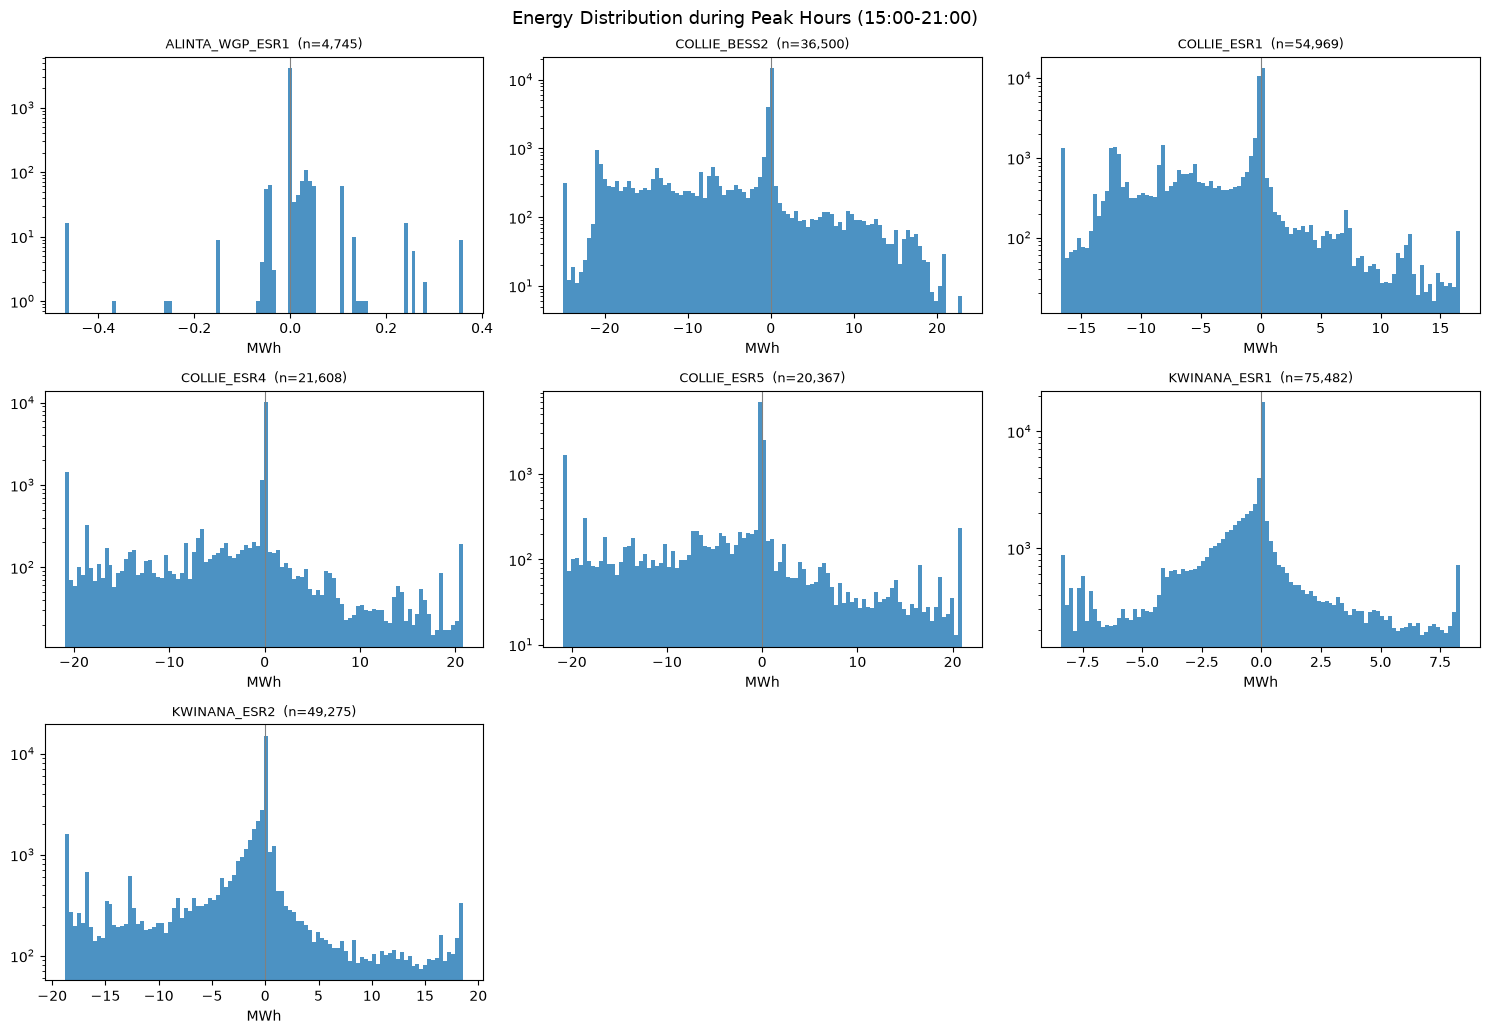

In [125]:
plot_distribution_hist(
    df=peak,
    col="MWh",
    x_label="MWh",
    title="Energy Distribution during Peak Hours (15:00-21:00)",
    battery_codes=esr_battery_codes
)

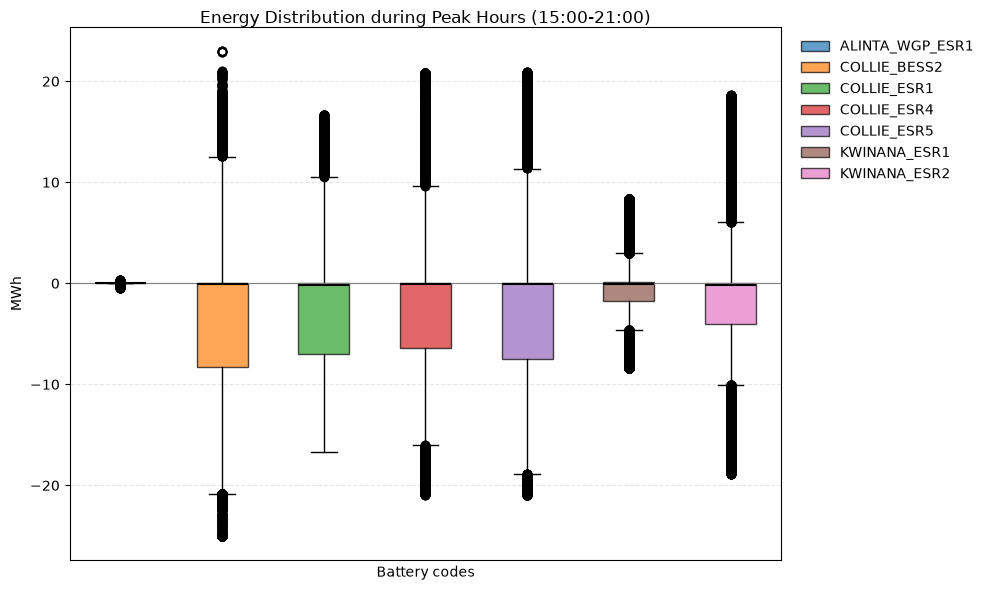

In [144]:
build_boxplot(
    df=peak,
    col="MWh",
    title="Energy Distribution during Peak Hours (15:00-21:00)",
    y_label="MWh",
    battery_codes=esr_battery_codes,
    show_outliers=True
)

### Average Power Profile

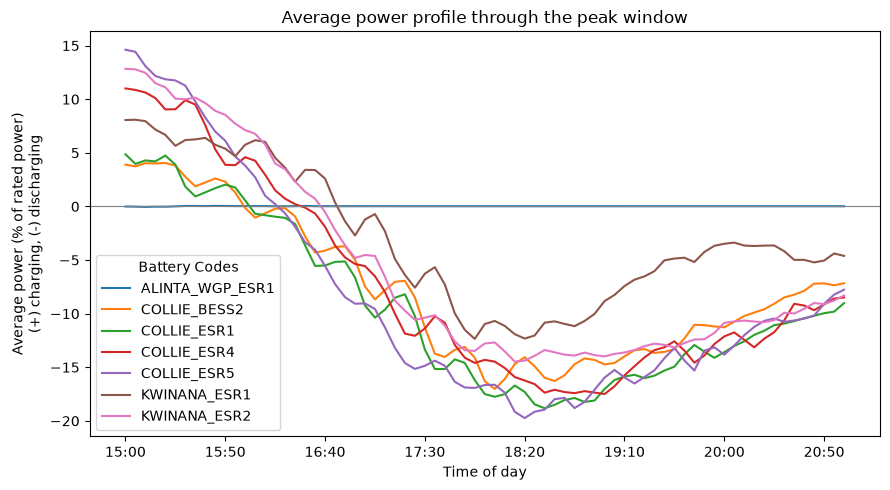

In [141]:
avg_charge_profile(
    df=esr,
    start_time="15:00",
    end_time="21:00",
    y_label="power (% of rated power)",
    title="power profile through the peak window"
)

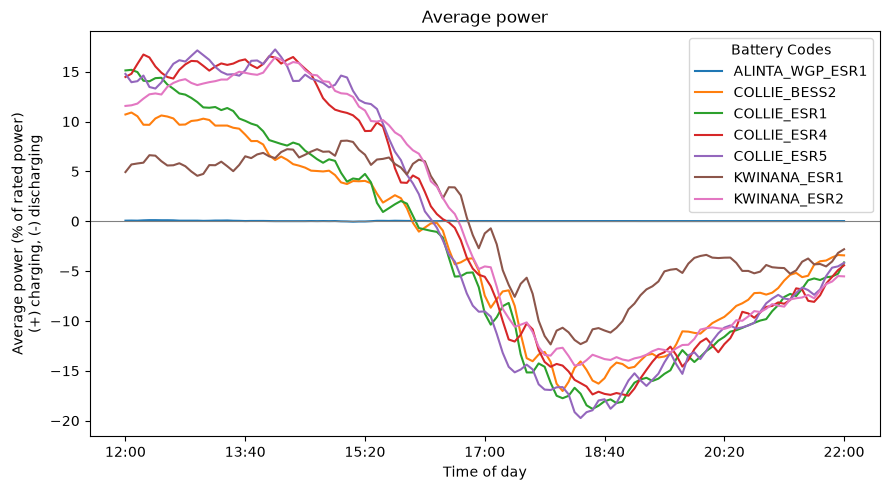

In [142]:
avg_charge_profile(
    df=esr,
    start_time="12:00",
    end_time="22:00",
    y_label="power (% of rated power)",
    title="power"
)

Note: this violin plot does not represent the scale of distribution. It only reflects the shape of the distribution.


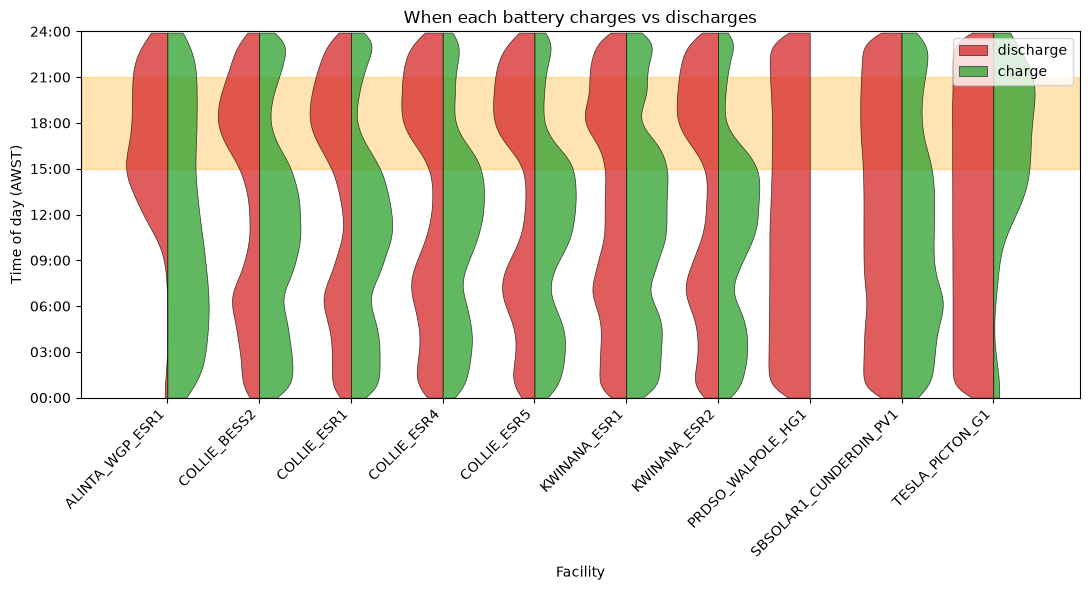

(None, None)

In [128]:
IDLE_THRESHOLD = 1e-4
active = df[df["MW"].abs() > IDLE_THRESHOLD].copy()
active["hour"] = active.index.hour + active.index.minute / 60

codes = sorted(active["code"].unique())


def half_violin(ax, subset, codes, side, colour, label):
    """Draw violins clipped to one side of their centreline."""
    g = subset.groupby("code")["hour"]
    positions, series = [], []
    for i, c in enumerate(codes, start=1):
        if c in g.groups and len(g.get_group(c)) > 1:
            positions.append(i)
            series.append(g.get_group(c).values)
    if not series:
        return

    parts = ax.violinplot(series, positions=positions, widths=0.9,
                          showmedians=False, showextrema=False)

    for body, pos in zip(parts["bodies"], positions):
        verts = body.get_paths()[0].vertices
        if side == "left":
            verts[:, 0] = np.clip(verts[:, 0], -np.inf, pos)
        else:
            verts[:, 0] = np.clip(verts[:, 0], pos, np.inf)
        body.set_facecolor(colour)
        body.set_alpha(0.75)
        body.set_edgecolor("black")
        body.set_linewidth(0.5)

    parts["bodies"][0].set_label(label)


fig, ax = plt.subplots(figsize=(11, 6))

discharge = active[active["MW"] < 0]
charge = active[active["MW"] > 0]

half_violin(ax, discharge, codes, "left", "tab:red", "discharge")
half_violin(ax, charge, codes, "right", "tab:green", "charge")

ax.set_xticks(range(1, len(codes) + 1), codes, rotation=45, ha="right")
ax.set_yticks(range(0, 25, 3), [f"{h:02d}:00" for h in range(0, 25, 3)])
ax.set_ylim(0, 24)
ax.axhspan(15, 21, color="orange", alpha=0.30, zorder=0)
ax.set_ylabel("Time of day (AWST)")
ax.set_xlabel("Facility")
ax.set_title("When each battery charges vs discharges")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(plots_dir/"violinplot.png", dpi=200)

(print("Note: this violin plot does not represent the scale of distribution. It only reflects the shape of the distribution."),
plt.show())

---

(array([[0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
         0.000000e+00, 1.690272e+06, 0.000000e+00, 0.000000e+00,
         0.000000e+00, 0.000000e+00],
        [0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
         0.000000e+00, 1.690272e+06, 0.000000e+00, 0.000000e+00,
         0.000000e+00, 0.000000e+00],
        [0.000000e+00, 0.000000e+00, 0.000000e+00, 2.650600e+04,
         1.389320e+05, 1.428136e+06, 8.482100e+04, 1.187700e+04,
         0.000000e+00, 0.000000e+00],
        [0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
         0.000000e+00, 4.466880e+05, 5.227200e+05, 0.000000e+00,
         4.112640e+05, 3.096000e+05],
        [4.000000e+00, 1.000000e+00, 0.000000e+00, 1.000000e+01,
         6.160000e+04, 1.628657e+06, 0.000000e+00, 0.000000e+00,
         0.000000e+00, 0.000000e+00]]),
 array([-686.4 , -557.76, -429.12, -300.48, -171.84,  -43.2 ,   85.44,
         214.08,  342.72,  471.36,  600.  ]),
 <a list of 5 BarContainer objects>)

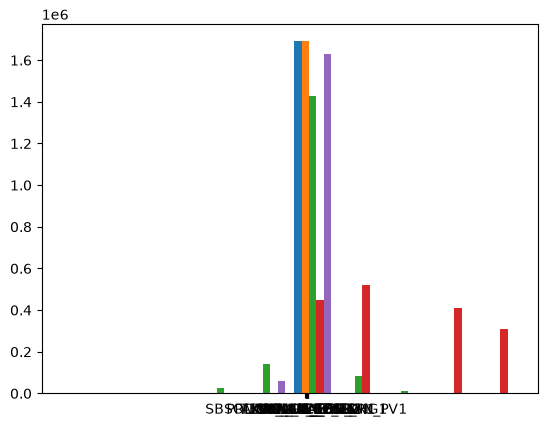

In [145]:
plt.hist(df)